In [58]:
import pandas as pd;
import numpy as np;
import seaborn as sns;
from sklearn.model_selection import train_test_split;
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("titanic_data_updated.csv")
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
48,49,no,third,"Samaan, Mr. Youssef",male,NaN,2,0,2662,21.6792,NaN,C
510,511,yes,third,"Daly, Mr. Eugene Patrick",male,29.0,0,0,382651,7.7500,NaN,Q
858,859,yes,third,"Baclini, Mrs. Solomon (Latifa Qurban)",female,24.0,0,3,2666,19.2583,NaN,C
865,866,yes,second,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.0000,NaN,S
156,157,yes,third,"Gilnagh, Miss. Katherine ""Katie""",female,16.0,0,0,35851,7.7333,NaN,Q
430,431,yes,first,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,0,0,110564,26.5500,C52,S
290,291,yes,first,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
763,764,yes,first,"Carter, Mrs. William Ernest (Lucile Polk)",female,36.0,1,2,113760,120.0000,B96 B98,S
295,296,no,first,"Lewy, Mr. Ervin G",male,NaN,0,0,PC 17612,27.7208,NaN,C
205,206,no,third,"Strom, Miss. Telma Matilda",female,2.0,0,1,347054,10.4625,G6,S


In [24]:
df.drop(["PassengerId","Name","Ticket","Cabin"],axis=True,inplace=True)

In [25]:
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [29]:
# find features ;
X = df.drop(["Survived"],axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,S
887,first,female,19.0,0,0,30.0000,S
888,third,female,NaN,1,2,23.4500,S
889,first,male,26.0,0,0,30.0000,C


In [43]:
# find target ;
Y = df['Survived']
Y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [51]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Pclass       0
Sex          0
Age         37
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64


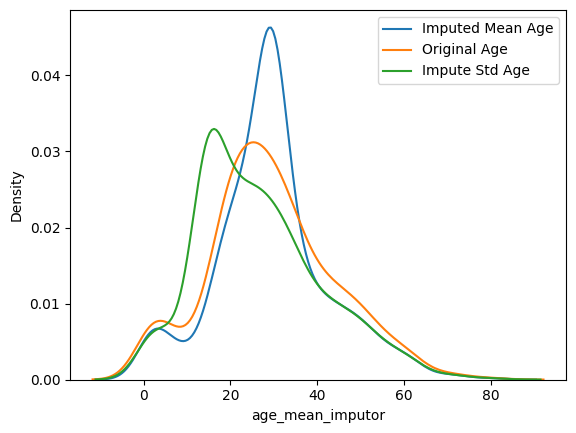

In [74]:
# df.fillna(value, method=None, inplace=False)
age_mean = X_train['Age'].mean()
age_std= X_train['Age'].std()
X_train['age_mean_imputor'] = X_train['Age'].fillna(age_mean)
X_train['age_std_imputor'] = X_train['Age'].fillna(age_std)
# plt.figure(figsize=(8,5))

sns.kdeplot(data=X_train, x="age_mean_imputor", label="Imputed Mean Age")
sns.kdeplot(data=X_train, x="Age", label="Original Age")
sns.kdeplot(data=X_train, x="age_std_imputor", label="Impute Std Age")

plt.legend()
plt.show()

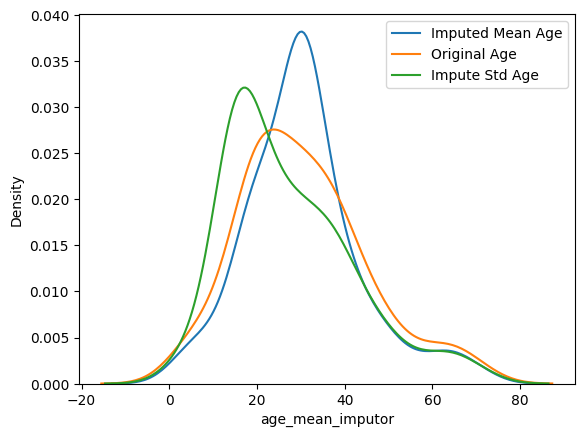

In [75]:
age_mean = X_test['Age'].mean()
age_std= X_test['Age'].std()
X_test['age_mean_imputor'] = X_test['Age'].fillna(age_mean)
X_test['age_std_imputor'] = X_test['Age'].fillna(age_std)
# plt.figure(figsize=(8,5))

sns.kdeplot(data=X_test, x="age_mean_imputor", label="Imputed Mean Age")
sns.kdeplot(data=X_test, x="Age", label="Original Age")
sns.kdeplot(data=X_test, x="age_std_imputor", label="Impute Std Age")

plt.legend()
plt.show()

In [77]:
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(missing_values=np.nan , strategy='mean')

age_imputer.fit(X_train[['Age']])

X_train['Age'] = age_imputer.transform(X_train[['Age']])